# Applying the trained models

## 0. Prerrequisites

In [ ]:
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import torch

import astropy.units as u

from pathlib import Path
import sys
# Add parent directories to path
sys.path.append("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN")
from utils.modest_data import ModestData
from models.pinn_mscnn_model import PhysicsInformedMSCNN
from utils.normalizer import MhdNormalizer, StokesNormalizer

## 1. Upload data

In [ ]:
data_path = Path("/scratchsan/observatorio/juagudeloo/data")

In [ ]:
modest = ModestData()
modest.load_all(apply_mask=False)
print("Modest data loaded.")

Modest data loaded.


In [ ]:
modest.continuum.shape

(390, 858)

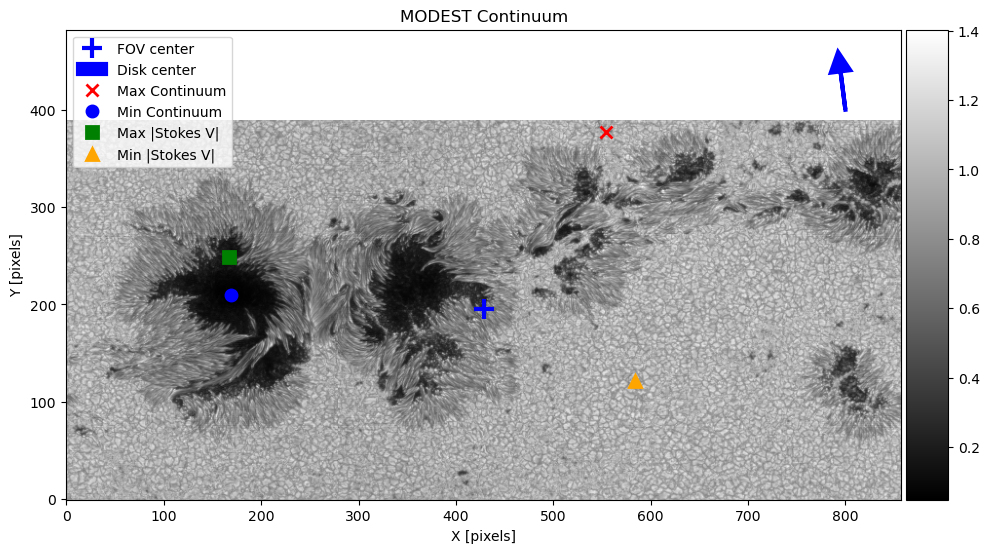

In [ ]:
y_center_fov_arcsec = -126.0
x_center_fov_arcsec = 16.0
pixel_scale = 0.32
x_center_fov_pixel = modest.continuum.shape[1] / 2
y_center_fov_pixel = modest.continuum.shape[0] / 2
x_disk_offset_arcsec = 0 - x_center_fov_arcsec
y_disk_offset_arcsec = 0 - y_center_fov_arcsec
x_disk_offset_pixels = x_disk_offset_arcsec / pixel_scale
y_disk_offset_pixels = y_disk_offset_arcsec / pixel_scale
x_disk_center = x_center_fov_pixel + x_disk_offset_pixels
y_disk_center = y_center_fov_pixel + y_disk_offset_pixels
arrow_start_x = 800
arrow_start_y = 400
arrow_dx = x_disk_offset_pixels/10
arrow_dy = y_disk_offset_pixels/10

modest.plot_continuum(x_center_fov_pixel=x_center_fov_pixel,
                     y_center_fov_pixel=y_center_fov_pixel,
                     disk_center = (x_disk_center, y_disk_center),
                     arrow_params=(arrow_start_x, arrow_start_y, arrow_dx, arrow_dy))

In [ ]:
# Load intermediate state
mhd_normalizer = MhdNormalizer()
mhd_normalizer.load(data_path / "normalization_stats/mhd_normalization.json")

# Load intermediate state
stokes_normalizer = StokesNormalizer()
stokes_normalizer.load(data_path / "normalization_stats/stokes_normalization.json")

normalized_stokes = stokes_normalizer.transform(modest.obs_stokes)


Per-τ normalization statistics loaded from /scratchsan/observatorio/juagudeloo/data/normalization_stats/mhd_normalization.json
Optical depth levels: 21
Stokes normalization statistics loaded from /scratchsan/observatorio/juagudeloo/data/normalization_stats/stokes_normalization.json


In [ ]:
modest.sample_pixels

{'max_continuum': {'y': 377.0, 'x': 554.0, 'label': 'Max Continuum'},
 'min_continuum': {'y': 210.0, 'x': 169.0, 'label': 'Min Continuum'},
 'max_polarization': {'y': 249.0, 'x': 167.0, 'label': 'Max |Stokes V|'},
 'min_polarization': {'y': 121.0, 'x': 584.0, 'label': 'Min |Stokes V|'}}

Plotting pixel max_continuum at (x=554, y=377)
Plotting pixel min_continuum at (x=169, y=210)
Plotting pixel max_polarization at (x=167, y=249)
Plotting pixel min_polarization at (x=584, y=121)


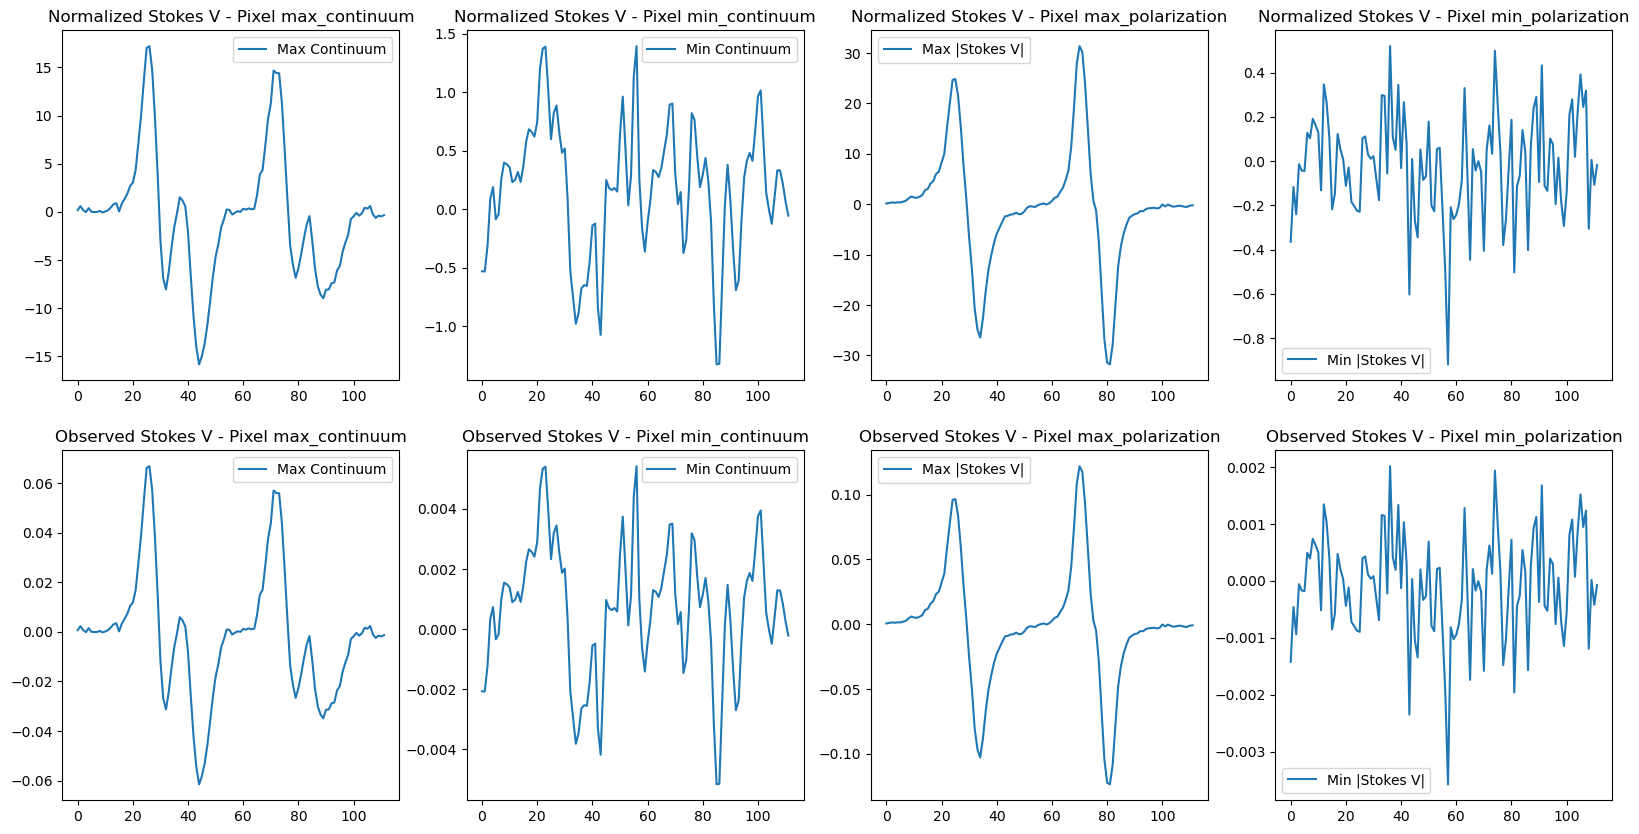

In [ ]:
fig, ax = plt.subplots(2,len(modest.sample_pixels.keys()), figsize=(5*len(modest.sample_pixels.keys()), 10))

for i, key in enumerate(modest.sample_pixels.keys()):
    ix, iy = int(modest.sample_pixels[key]["x"]), int(modest.sample_pixels[key]["y"])
    print(f"Plotting pixel {key} at (x={ix}, y={iy})")
    ax[0,i].plot(normalized_stokes["V"][iy,ix,:], label=modest.sample_pixels[key]["label"])
    ax[0,i].set_title(f"Normalized Stokes V - Pixel {key}")
    ax[0,i].legend()
    ax[1,i].plot(modest.obs_stokes["V"][iy,ix,:], label=modest.sample_pixels[key]["label"])
    ax[1,i].set_title(f"Observed Stokes V - Pixel {key}")
    ax[1,i].legend()

## 2. Instantiate the model

In [ ]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"
print(f"Using device: {device}")

# Instantiate the Physics-Informed MSCNN model
model = PhysicsInformedMSCNN(
    scales=[1, 2, 3],                           # Multi-scale coarse-graining
    in_channels=2,                              # I and V Stokes parameters
    c1_filters=16,                              # Filters in first conv block
    c2_filters=32,                              # Filters in second conv block
    kernel_size=5,                              # Convolution kernel size
    pool_size=2,                                # MaxPool kernel size
    n_linear_layers=4,                          # Dense layers for final mapping
    output_features=3*21,                       # 3 parameters × 21 heights = 63 outputs
    input_length=112,                           # Spectral dimension of Stokes profiles
    
    # Physics-informed parameters
    central_wavelength=6301.5*u.Angstrom,      # Fe I 6301.5 Å
    lande_factor=1.67,                          # Landé g-factor
    wl_range=(15, 60),                          # Wavelength indices for WFA/Doppler
    lambda_reg=0.1,                             # Regularization weight
    use_physics='both',                         # Use both WFA and Doppler (can be None, 'wfa', 'doppler', or 'both')

    # Dropout for uncertainty
    dropout_rate=0.2  # 20% dropout
).to(device)

print(f"Model instantiated on {device}")
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Regularization weight (lambda_reg): {model.lambda_reg}")
print(f"Physics mode: {model.use_physics}")
model_path = "/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation/no_physics/final_model.pth"

# Load the checkpoint dictionary first
checkpoint = torch.load(model_path, map_location=device)

# Extract the model state dict and load it
model.load_state_dict(checkpoint['model_state_dict'])

# Optionally, you can also access the test metrics
test_metrics = checkpoint['test_metrics']
print(f"Test metrics from training: {test_metrics}")

# Set to evaluation mode
model.eval()
print("Model loaded successfully.")

Using device: cpu
Model instantiated on cpu
Total trainable parameters: 7,318,223
Regularization weight (lambda_reg): 0.1
Physics mode: both
Test metrics from training: {'blos_rrmse_tau_avg': 29779.366531393567, 'vlos_rrmse_tau_avg': 1.324636533062672, 'blos_correlation': 0.06943092216475712, 'vlos_correlation': 0.011117139868323063, 'blos_rmse': 887279.0878523405, 'vlos_rmse': 12.218733070185111}
Model loaded successfully.


In [ ]:
I_t = normalized_stokes["I"]
V_t = normalized_stokes["V"]
inputs = np.stack([I_t, V_t], axis=-1)  # Shape: (H, W, 2)
inputs_tensor = torch.tensor(inputs, dtype=torch.float32).to(device)  # Shape: (1, H, W, 2)
inputs_tensor = inputs_tensor.permute(0,1,3,2)  # Shape: (1, 2, H, W)
H, W, Nlambda, Nstokes = inputs.shape[0], inputs.shape[1], inputs.shape[2], inputs.shape[3]
inputs_tensor = inputs_tensor.reshape(H*W, Nstokes,Nlambda)  # Shape: (1, H, W, Nlambda, Nstokes)
print(f"Input tensor shape: {inputs_tensor.shape}")

Input tensor shape: torch.Size([334620, 2, 112])


In [ ]:
# Inference WITH uncertainty (slower) - with batching
batch_size = 512  # Use smaller batch for uncertainty estimation
model.eval()

all_stochastic_predictions = []

print("Starting inference WITH uncertainty...")
with torch.no_grad():
    for i in range(0, len(inputs_tensor), batch_size):
        batch = inputs_tensor[i:i+batch_size]
        # Returns shape: (stochastic_steps=30, batch_size, 63)
        batch_predictions = model(batch, stocastic_generation=True, stocastic_steps=30)
        all_stochastic_predictions.append(batch_predictions.cpu())
        
        # Optional: print progress
        if (i // batch_size) % 1000 == 0:
            print(f"Processed {i}/{len(inputs_tensor)} pixels ({100*i/len(inputs_tensor):.1f}%)")

# Concatenate all batches: shape (30, H*W, 63)
stochastic_predictions = torch.cat(all_stochastic_predictions, dim=1)
print(f"Stochastic predictions shape: {stochastic_predictions.shape}")  # (30, H*W, 63)

# Denormalize each stochastic sample
n_heights = 21
n_stochastic = stochastic_predictions.shape[0]  # 30
n_pixels = stochastic_predictions.shape[1]  # H*W

# Reshape to (30*H*W, 63) for batch denormalization
predictions_reshaped = stochastic_predictions.reshape(-1, 63).numpy()

# Denormalize using the MHD normalizer
denorm_dict = mhd_normalizer.inverse_transform(
    predictions_reshaped, 
    param_order=['T', 'Vz', 'Bz']
)

# Reshape back to (30, H*W, 3, 21) for statistics computation
denorm_stochastic = {}
for param in ['T', 'Vz', 'Bz']:
    # denorm_dict[param] has shape (30*H*W, 21)
    denorm_stochastic[param] = denorm_dict[param].reshape(n_stochastic, n_pixels, n_heights)

print("Denormalization complete.")

# Compute mean and std across the 30 stochastic samples (axis=0)
mean_atm = {}
std_atm = {}

for param in ['T', 'Vz', 'Bz']:
    # Compute statistics along the stochastic dimension (axis=0)
    mean_atm[param] = np.mean(denorm_stochastic[param], axis=0)  # (H*W, 21)
    std_atm[param] = np.std(denorm_stochastic[param], axis=0)    # (H*W, 21)
    
    # Reshape to spatial dimensions
    mean_atm[param] = mean_atm[param].reshape(H, W, n_heights)
    std_atm[param] = std_atm[param].reshape(H, W, n_heights)

print(f"Mean predictions shape: {mean_atm['T'].shape}")  # (H, W, 21)
print(f"Std predictions shape: {std_atm['T'].shape}")    # (H, W, 21)
print(f"Temperature mean range: {mean_atm['T'].min():.1f} - {mean_atm['T'].max():.1f} K")
print(f"Temperature std range: {std_atm['T'].min():.2f} - {std_atm['T'].max():.2f} K")

Starting inference WITH uncertainty...
Processed 0/334620 pixels (0.0%)


Stochastic predictions shape: torch.Size([30, 334620, 63])
Denormalization complete.
Mean predictions shape: (390, 858, 21)
Std predictions shape: (390, 858, 21)
Temperature mean range: 3376.1 - 6551.6 K
Temperature std range: 11.67 - 288.35 K


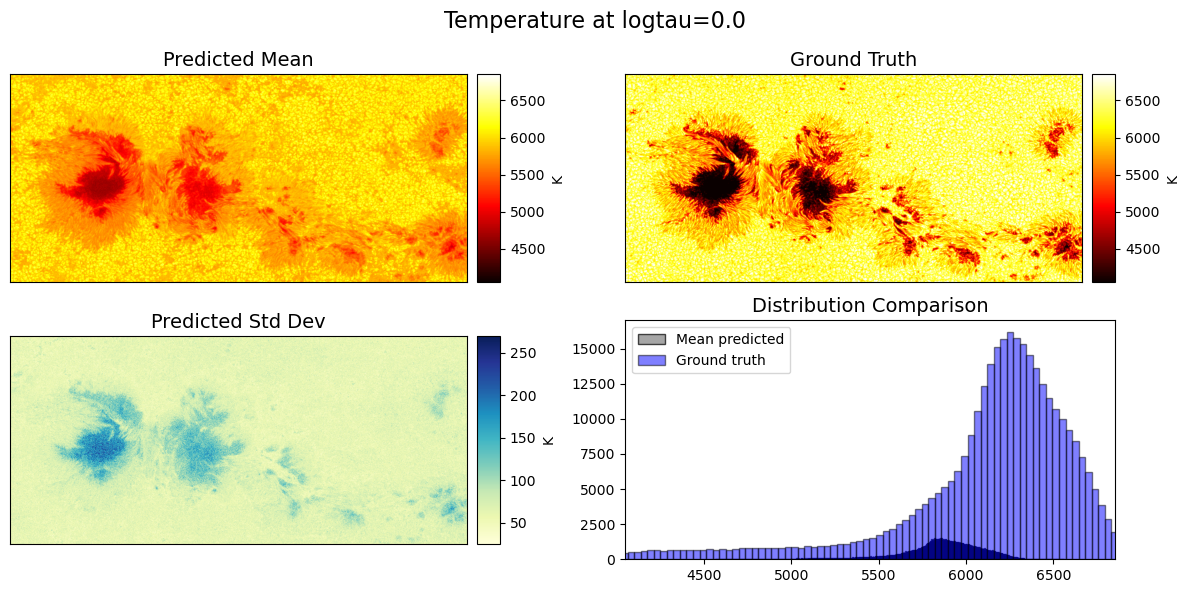

: 

: 

: 

: 

In [ ]:
mag_to_plot = "T"
od_to_plot = 0  # Example: logtau = -1.0
logtau = np.arange(-2,0.1,0.1)
logtau_idx = np.argmin(np.abs(logtau - (od_to_plot)))
title_map = {"T": "Temperature",
             "Vz": "Line-of-sight Velocity",
             "Bz": "Line-of-sight Magnetic Field"}
units_map = {"T": "K",
             "Vz": "km/s",
             "Bz": "G"}

modest_key_mapping = {"T": "T",
                      "Vz": "Vlos", 
                      "Bz": "Blos"}

color_mapping = {"T": "hot",
                 "Vz": "bwr_r",
                 "Bz": "PiYG"}

uncertainty_cmap = {"T": "YlGnBu",
                    "Vz": "BrBG",
                    "Bz": "BrBG"} 

q0, q99 = np.percentile(modest.spinor_atm[modest_key_mapping[mag_to_plot]][od_to_plot], [1, 99])

if mag_to_plot in ["Vz", "Bz"]:
    vmax = max(np.abs(q0), np.abs(q99))
    vmin = -vmax
if mag_to_plot == "T":
    vmin, vmax = q0, q99

# Mean plotting
fig, ax = plt.subplots(2,2,figsize=(12,6))
fig.suptitle(f"{title_map[mag_to_plot]} at logtau={logtau[logtau_idx]:.1f}", fontsize=16)
im0 = ax[0,0].imshow(mean_atm[mag_to_plot][:,:,logtau_idx], cmap=color_mapping[mag_to_plot], vmax = vmax, vmin = vmin)
divider = make_axes_locatable(ax[0,0])
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(im0, cax=cax, label = units_map[mag_to_plot])
ax[0,0].set_xticks([])
ax[0,0].set_yticks([])
ax[0,0].set_title("Predicted Mean", fontsize=14)

im1 = ax[0,1].imshow(modest.spinor_atm[modest_key_mapping[mag_to_plot]][od_to_plot], cmap=color_mapping[mag_to_plot], vmax = vmax, vmin = vmin)
divider = make_axes_locatable(ax[0,1])
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(im1, cax=cax, label = units_map[mag_to_plot])
ax[0,1].set_xticks([])
ax[0,1].set_yticks([])
ax[0,1].set_title("Ground Truth", fontsize=14)

im2 = ax[1,0].imshow(std_atm[mag_to_plot][:,:,logtau_idx], cmap=uncertainty_cmap[mag_to_plot])
divider = make_axes_locatable(ax[1,0])
cax2 = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(im2, cax=cax2, label = units_map[mag_to_plot])
ax[1,0].set_xticks([])
ax[1,0].set_yticks([])
ax[1,0].set_title("Predicted Std Dev", fontsize=14)

# distribution plotting
ax[1,1].hist(mean_atm[mag_to_plot][:,:,logtau_idx].flatten(), bins=1000, color='gray', edgecolor='black', alpha = 0.7, label = "Mean predicted")
ax[1,1].hist(modest.spinor_atm[modest_key_mapping[mag_to_plot]][od_to_plot].flatten(), bins=100, color='blue', edgecolor='black', alpha = 0.5, label = "Ground truth")
ax[1,1].set_xlim(vmin, vmax)
ax[1,1].legend()
ax[1,1].set_title("Distribution Comparison", fontsize=14)

plt.tight_layout()
plt.show()

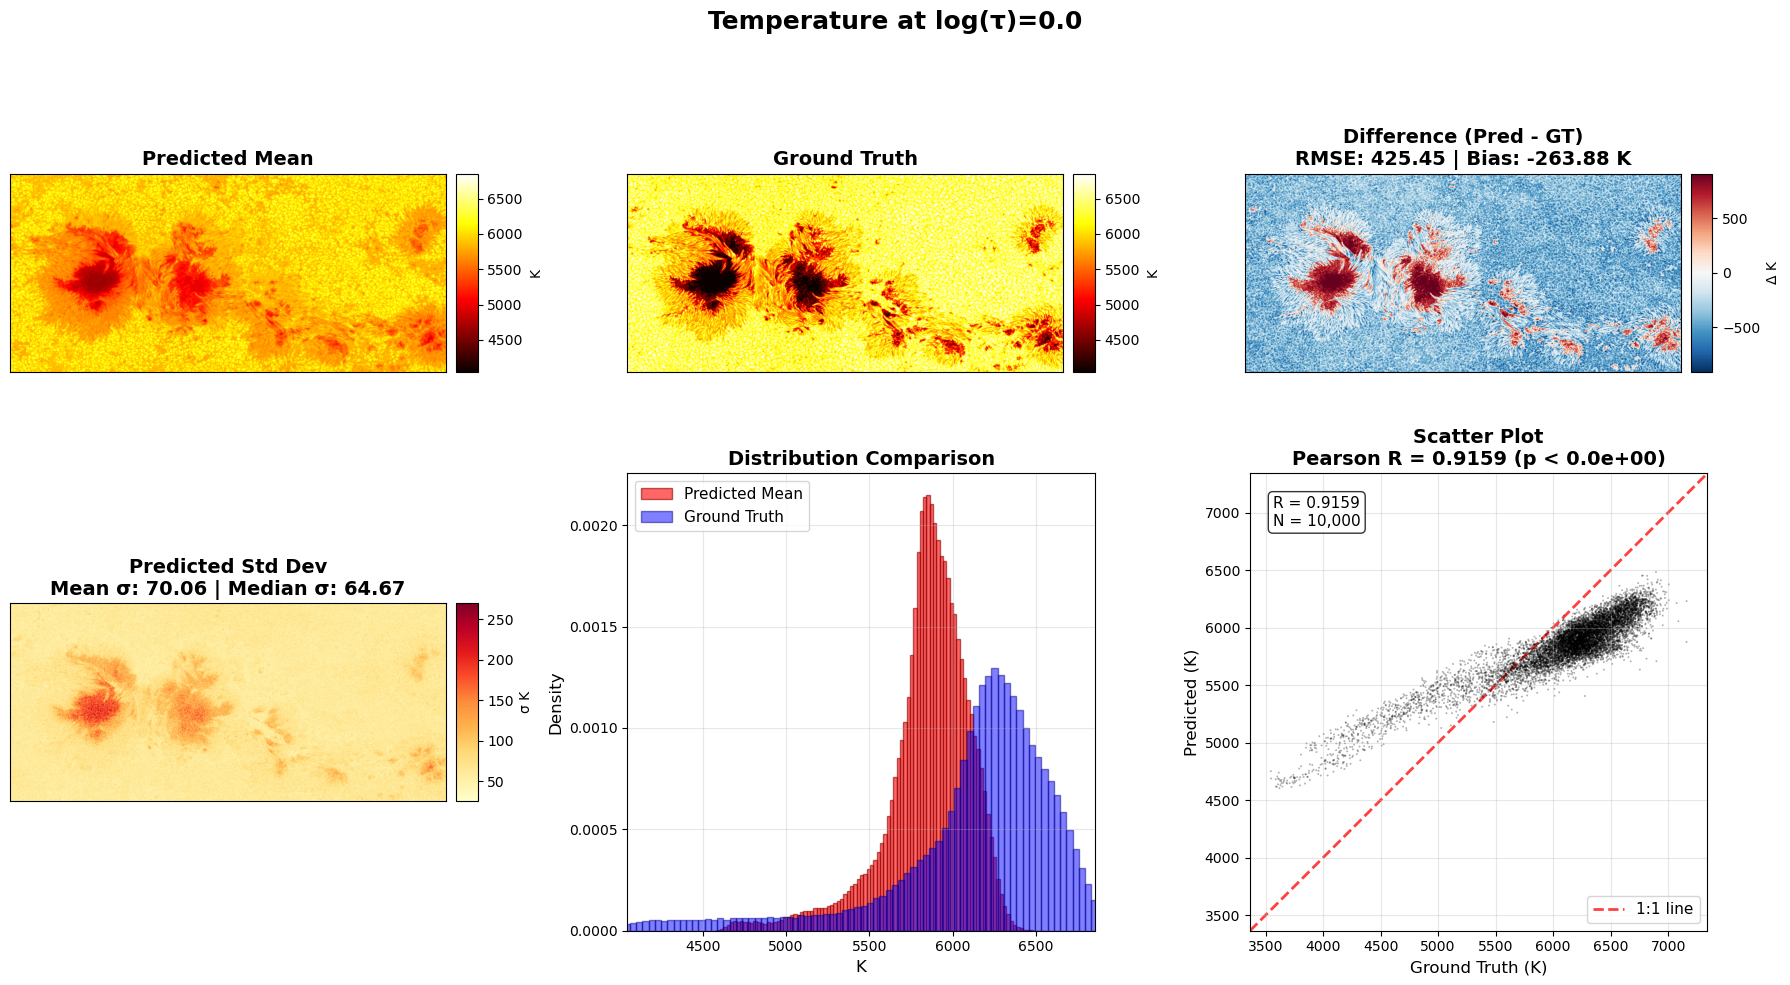


Summary Statistics for Temperature at log(τ)=0.0
Pearson R:   0.9159 (p-value: 0.00e+00)
RMSE:        425.450 K
Bias:        -263.879 K
Mean σ:      70.056 K
Median σ:    64.668 K



: 

: 

: 

: 

In [ ]:
from scipy.stats import pearsonr

def plot_prediction_comparison(
    mean_atm: dict,
    std_atm: dict,
    ground_truth: dict,
    mag_to_plot: str = "T",
    od_to_plot: float = 0.0,
    logtau: np.ndarray = None,
    figsize: tuple = (18, 10)
):
    """
    Plot comprehensive comparison between predicted mean, ground truth, and uncertainty.
    
    Parameters
    ----------
    mean_atm : dict
        Dictionary with keys ['T', 'Vz', 'Bz'] containing mean predictions.
        Each array has shape (H, W, n_heights).
    std_atm : dict
        Dictionary with keys ['T', 'Vz', 'Bz'] containing standard deviations.
        Each array has shape (H, W, n_heights).
    ground_truth : dict
        Dictionary with keys ['T', 'Vlos', 'Blos'] containing ground truth data.
        Each array has shape (n_heights, H, W).
    mag_to_plot : str, optional
        Parameter to plot: 'T', 'Vz', or 'Bz'. Default is 'T'.
    od_to_plot : float, optional
        Optical depth value to plot. Default is 0.0.
    logtau : np.ndarray, optional
        Array of log(tau) values. If None, uses default range.
    figsize : tuple, optional
        Figure size. Default is (18, 10).
    """
    if logtau is None:
        logtau = np.arange(-2, 0.1, 0.1)
    
    logtau_idx = np.argmin(np.abs(logtau - od_to_plot))
    
    # Mapping dictionaries
    title_map = {
        "T": "Temperature",
        "Vz": "Line-of-sight Velocity",
        "Bz": "Line-of-sight Magnetic Field"
    }
    
    units_map = {
        "T": "K",
        "Vz": "km/s",
        "Bz": "G"
    }
    
    modest_key_mapping = {
        "T": "T",
        "Vz": "Vlos", 
        "Bz": "Blos"
    }
    
    color_mapping = {
        "T": "hot",
        "Vz": "bwr_r",
        "Bz": "PiYG"
    }
    
    uncertainty_cmap = {
        "T": "YlOrRd",
        "Vz": "viridis",
        "Bz": "viridis"
    }
    
    # Get data
    pred_mean = mean_atm[mag_to_plot][:, :, logtau_idx]
    pred_std = std_atm[mag_to_plot][:, :, logtau_idx]
    gt = ground_truth[modest_key_mapping[mag_to_plot]][od_to_plot]
    
    # Compute difference
    difference = pred_mean - gt
    
    # Compute color limits from ground truth
    q0, q99 = np.percentile(gt, [1, 99])
    
    if mag_to_plot in ["Vz", "Bz"]:
        vmax = max(np.abs(q0), np.abs(q99))
        vmin = -vmax
    else:  # Temperature
        vmin, vmax = q0, q99
    
    # Compute difference color limits (symmetric)
    diff_max = np.percentile(np.abs(difference), 99)
    diff_vmin, diff_vmax = -diff_max, diff_max
    
    # Compute metrics
    rmse = np.sqrt(np.mean(difference**2))
    bias = np.mean(difference)
    corr, p_value = pearsonr(pred_mean.flatten(), gt.flatten())
    
    # Create figure with 2x3 subplots
    fig, ax = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle(
        f"{title_map[mag_to_plot]} at log(τ)={logtau[logtau_idx]:.1f}", 
        fontsize=18, 
        fontweight='bold'
    )
    
    # 1. Predicted Mean
    im0 = ax[0, 0].imshow(pred_mean, cmap=color_mapping[mag_to_plot], vmax=vmax, vmin=vmin)
    divider = make_axes_locatable(ax[0, 0])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im0, cax=cax, label=units_map[mag_to_plot])
    ax[0, 0].set_xticks([])
    ax[0, 0].set_yticks([])
    ax[0, 0].set_title("Predicted Mean", fontsize=14, fontweight='bold')
    
    # 2. Ground Truth
    im1 = ax[0, 1].imshow(gt, cmap=color_mapping[mag_to_plot], vmax=vmax, vmin=vmin)
    divider = make_axes_locatable(ax[0, 1])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im1, cax=cax, label=units_map[mag_to_plot])
    ax[0, 1].set_xticks([])
    ax[0, 1].set_yticks([])
    ax[0, 1].set_title("Ground Truth", fontsize=14, fontweight='bold')
    
    # 3. Difference (Prediction - Ground Truth)
    im2 = ax[0, 2].imshow(difference, cmap='RdBu_r', vmax=diff_vmax, vmin=diff_vmin)
    divider = make_axes_locatable(ax[0, 2])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im2, cax=cax, label=f"Δ {units_map[mag_to_plot]}")
    ax[0, 2].set_xticks([])
    ax[0, 2].set_yticks([])
    ax[0, 2].set_title(
        f"Difference (Pred - GT)\nRMSE: {rmse:.2f} | Bias: {bias:.2f} {units_map[mag_to_plot]}", 
        fontsize=14, 
        fontweight='bold'
    )
    
    # 4. Predicted Std Dev
    im3 = ax[1, 0].imshow(pred_std, cmap=uncertainty_cmap[mag_to_plot])
    divider = make_axes_locatable(ax[1, 0])
    cax2 = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im3, cax=cax2, label=f"σ {units_map[mag_to_plot]}")
    ax[1, 0].set_xticks([])
    ax[1, 0].set_yticks([])
    ax[1, 0].set_title(
        f"Predicted Std Dev\nMean σ: {np.mean(pred_std):.2f} | Median σ: {np.median(pred_std):.2f}", 
        fontsize=14, 
        fontweight='bold'
    )
    
    # 5. Distribution Comparison
    ax[1, 1].hist(
        pred_mean.flatten(), 
        bins=100, 
        color='red', 
        edgecolor='darkred', 
        alpha=0.6, 
        label="Predicted Mean",
        density=True
    )
    ax[1, 1].hist(
        gt.flatten(), 
        bins=100, 
        color='blue', 
        edgecolor='darkblue', 
        alpha=0.5, 
        label="Ground Truth",
        density=True
    )
    ax[1, 1].set_xlim(vmin, vmax)
    ax[1, 1].set_xlabel(units_map[mag_to_plot], fontsize=12)
    ax[1, 1].set_ylabel("Density", fontsize=12)
    ax[1, 1].legend(fontsize=11)
    ax[1, 1].set_title("Distribution Comparison", fontsize=14, fontweight='bold')
    ax[1, 1].grid(alpha=0.3)
    
    # 6. Scatter Plot: Ground Truth vs Predicted Mean
    # Downsample for faster plotting if needed
    n_samples = min(10000, pred_mean.size)
    indices = np.random.choice(pred_mean.size, n_samples, replace=False)
    gt_flat = gt.flatten()[indices]
    pred_flat = pred_mean.flatten()[indices]
    
    ax[1, 2].scatter(gt_flat, pred_flat, alpha=0.3, s=2, c='black', edgecolors='none')
    
    # Add 1:1 line
    lims = [
        np.min([ax[1, 2].get_xlim(), ax[1, 2].get_ylim()]),
        np.max([ax[1, 2].get_xlim(), ax[1, 2].get_ylim()])
    ]
    ax[1, 2].plot(lims, lims, 'r--', alpha=0.75, linewidth=2, zorder=0, label='1:1 line')
    ax[1, 2].set_xlim(lims)
    ax[1, 2].set_ylim(lims)
    ax[1, 2].set_xlabel(f"Ground Truth ({units_map[mag_to_plot]})", fontsize=12)
    ax[1, 2].set_ylabel(f"Predicted ({units_map[mag_to_plot]})", fontsize=12)
    ax[1, 2].set_title(
        f"Scatter Plot\nPearson R = {corr:.4f} (p < {p_value:.1e})", 
        fontsize=14, 
        fontweight='bold'
    )
    ax[1, 2].legend(fontsize=11, loc='lower right')
    ax[1, 2].grid(alpha=0.3)
    ax[1, 2].set_aspect('equal', adjustable='box')
    
    # Add correlation info box
    ax[1, 2].text(
        0.05, 0.95, 
        f"R = {corr:.4f}\nN = {n_samples:,}", 
        transform=ax[1, 2].transAxes, 
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*60}")
    print(f"Summary Statistics for {title_map[mag_to_plot]} at log(τ)={logtau[logtau_idx]:.1f}")
    print(f"{'='*60}")
    print(f"Pearson R:   {corr:.4f} (p-value: {p_value:.2e})")
    print(f"RMSE:        {rmse:.3f} {units_map[mag_to_plot]}")
    print(f"Bias:        {bias:.3f} {units_map[mag_to_plot]}")
    print(f"Mean σ:      {np.mean(pred_std):.3f} {units_map[mag_to_plot]}")
    print(f"Median σ:    {np.median(pred_std):.3f} {units_map[mag_to_plot]}")
    print(f"{'='*60}\n")

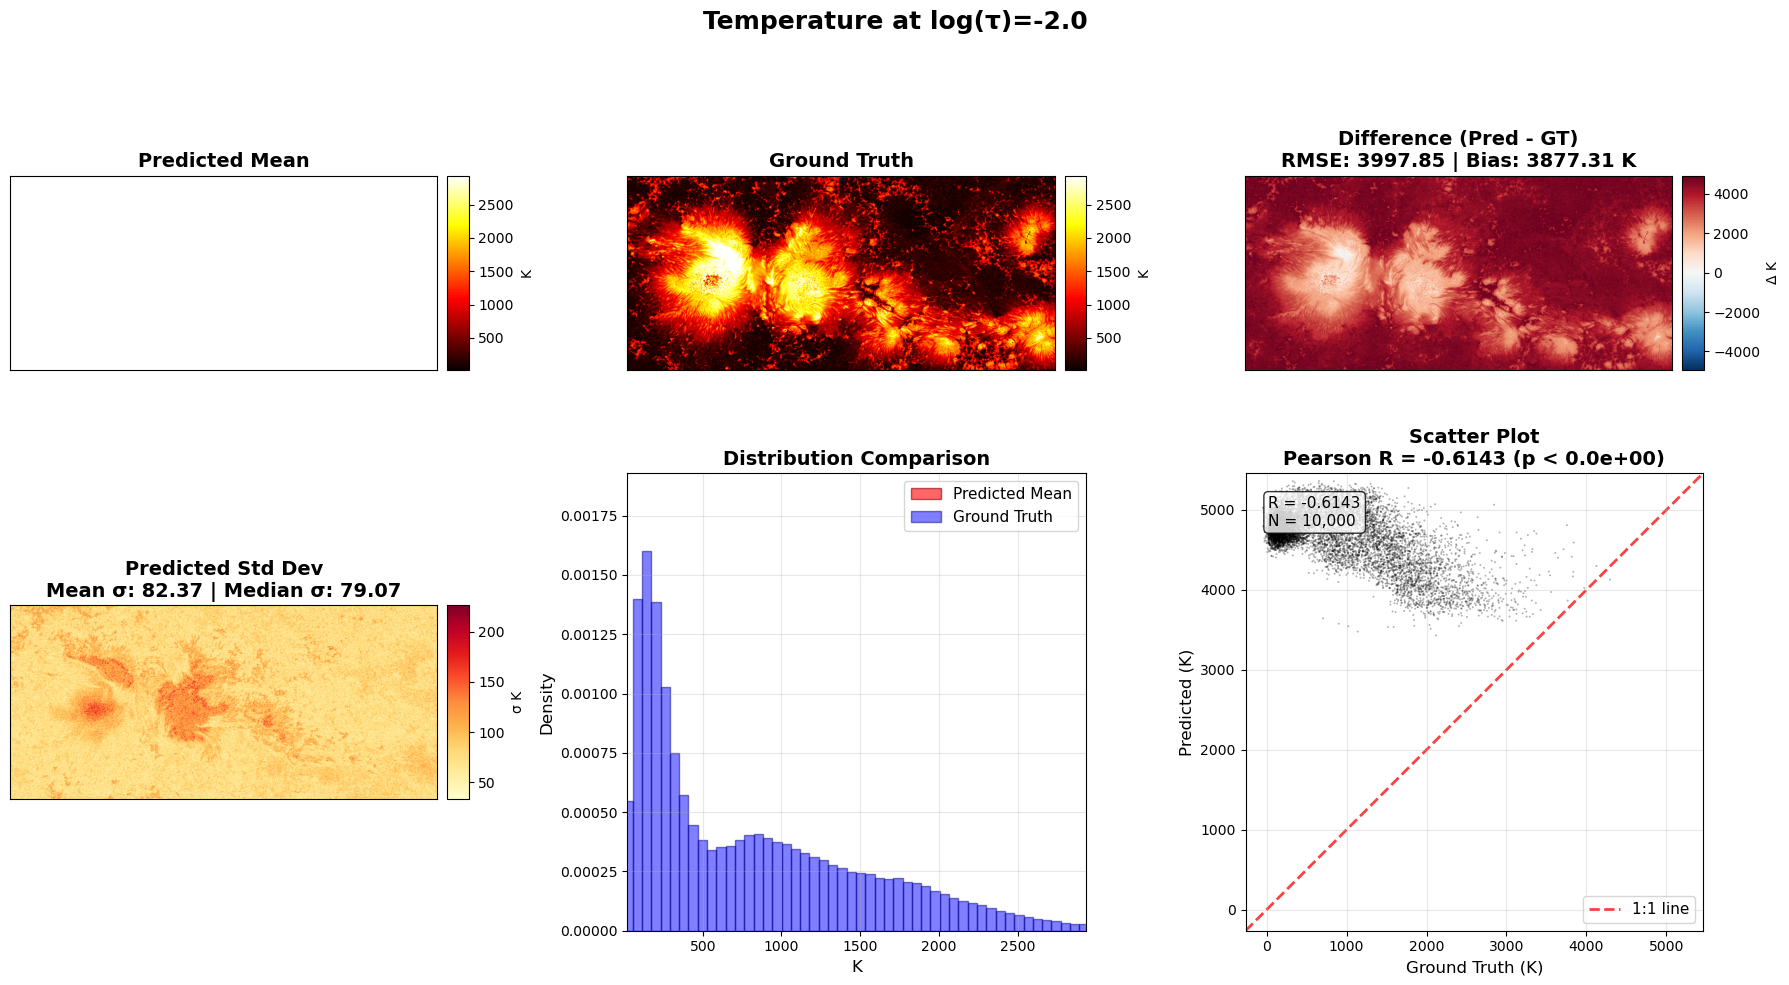


Summary Statistics for Temperature at log(τ)=-2.0
Pearson R:   -0.6143 (p-value: 0.00e+00)
RMSE:        3997.847 K
Bias:        3877.308 K
Mean σ:      82.374 K
Median σ:    79.071 K



: 

: 

: 

: 

In [ ]:

# Example usage:
plot_prediction_comparison(
    mean_atm=mean_atm,
    std_atm=std_atm,
    ground_truth=modest.spinor_atm,
    mag_to_plot="T",
    od_to_plot=-2.0,
    logtau=np.arange(-2, 0.1, 0.1),
    figsize=(18, 10)
)

In [ ]:
from scipy.stats import pearsonr

def plot_prediction_comparison(
    mean_atm: dict,
    std_atm: dict,
    ground_truth: dict,
    mag_to_plot: str = "T",
    od_to_plot: float = 0.0,
    logtau: np.ndarray = None,
    figsize: tuple = (12, 18)
):
    """
    Plot comprehensive comparison between predicted mean, ground truth, and uncertainty.
    
    Parameters
    ----------
    mean_atm : dict
        Dictionary with keys ['T', 'Vz', 'Bz'] containing mean predictions.
        Each array has shape (H, W, n_heights).
    std_atm : dict
        Dictionary with keys ['T', 'Vz', 'Bz'] containing standard deviations.
        Each array has shape (H, W, n_heights).
    ground_truth : dict
        Dictionary with keys ['T', 'Vlos', 'Blos'] containing ground truth data.
        Each array has shape (n_heights, H, W).
    mag_to_plot : str, optional
        Parameter to plot: 'T', 'Vz', or 'Bz'. Default is 'T'.
    od_to_plot : float, optional
        Optical depth value to plot. Default is 0.0.
    logtau : np.ndarray, optional
        Array of log(tau) values. If None, uses default range.
    figsize : tuple, optional
        Figure size. Default is (12, 18).
    """
    if logtau is None:
        logtau = np.arange(-2, 0.1, 0.1)
    
    logtau_idx = np.argmin(np.abs(logtau - od_to_plot))
    
    # Mapping dictionaries
    title_map = {
        "T": "Temperature",
        "Vz": "Line-of-sight Velocity",
        "Bz": "Line-of-sight Magnetic Field"
    }
    
    units_map = {
        "T": "K",
        "Vz": "km/s",
        "Bz": "G"
    }
    
    modest_key_mapping = {
        "T": "T",
        "Vz": "Vlos", 
        "Bz": "Blos"
    }
    
    color_mapping = {
        "T": "hot",
        "Vz": "bwr_r",
        "Bz": "PiYG"
    }
    
    uncertainty_cmap = {
        "T": "YlOrRd",
        "Vz": "viridis",
        "Bz": "viridis"
    }
    
    # Get data
    pred_mean = mean_atm[mag_to_plot][:, :, logtau_idx]
    pred_std = std_atm[mag_to_plot][:, :, logtau_idx]
    gt = ground_truth[modest_key_mapping[mag_to_plot]][od_to_plot]
    
    # Compute difference
    difference = pred_mean - gt
    
    # Compute color limits from ground truth
    q0, q99 = np.percentile(gt, [1, 99])
    
    if mag_to_plot in ["Vz",
     "Bz"]:
        vmax = max(np.abs(q0), np.abs(q99))
        vmin = -vmax
    else:  # Temperature
        vmin, vmax = q0, q99
    
    # Compute difference color limits (symmetric)
    diff_max = np.percentile(np.abs(difference), 99)
    diff_vmin, diff_vmax = -diff_max, diff_max
    
    # Compute metrics
    rmse = np.sqrt(np.mean(difference**2))
    bias = np.mean(difference)
    corr, p_value = pearsonr(pred_mean.flatten(), gt.flatten())
    
    # Create figure with 3x2 subplots
    fig, ax = plt.subplots(3, 2, figsize=figsize)
    fig.suptitle(
        f"{title_map[mag_to_plot]} at log(τ)={logtau[logtau_idx]:.1f}", 
        fontsize=18, 
        fontweight='bold'
    )
    
    # 1. Predicted Mean (top-left)
    im0 = ax[0, 0].imshow(pred_mean, cmap=color_mapping[mag_to_plot], vmax=vmax, vmin=vmin)
    divider = make_axes_locatable(ax[0, 0])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im0, cax=cax, label=units_map[mag_to_plot])
    ax[0, 0].set_xticks([])
    ax[0, 0].set_yticks([])
    ax[0, 0].set_title("Predicted Mean", fontsize=14, fontweight='bold')
    
    # 2. Ground Truth (top-right)
    im1 = ax[0, 1].imshow(gt, cmap=color_mapping[mag_to_plot], vmax=vmax, vmin=vmin)
    divider = make_axes_locatable(ax[0, 1])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im1, cax=cax, label=units_map[mag_to_plot])
    ax[0, 1].set_xticks([])
    ax[0, 1].set_yticks([])
    ax[0, 1].set_title("Ground Truth", fontsize=14, fontweight='bold')
    
    # 3. Difference (middle-left)
    im2 = ax[1, 0].imshow(difference, cmap='RdBu_r', vmax=diff_vmax, vmin=diff_vmin)
    divider = make_axes_locatable(ax[1, 0])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im2, cax=cax, label=f"Δ {units_map[mag_to_plot]}")
    ax[1, 0].set_xticks([])
    ax[1, 0].set_yticks([])
    ax[1, 0].set_title(
        f"Difference (Pred - GT)\nRMSE: {rmse:.2f} | Bias: {bias:.2f} {units_map[mag_to_plot]}", 
        fontsize=14, 
        fontweight='bold'
    )
    
    # 4. Predicted Std Dev (middle-right)
    im3 = ax[1, 1].imshow(pred_std, cmap=uncertainty_cmap[mag_to_plot])
    divider = make_axes_locatable(ax[1, 1])
    cax2 = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im3, cax=cax2, label=f"σ {units_map[mag_to_plot]}")
    ax[1, 1].set_xticks([])
    ax[1, 1].set_yticks([])
    ax[1, 1].set_title(
        f"Predicted Std Dev\nMean σ: {np.mean(pred_std):.2f} | Median σ: {np.median(pred_std):.2f}", 
        fontsize=14, 
        fontweight='bold'
    )
    
    # 5. Distribution Comparison (bottom-left)
    ax[2, 0].hist(
        pred_mean.flatten(), 
        bins=100, 
        color='red', 
        edgecolor='darkred', 
        alpha=0.6, 
        label="Predicted Mean",
        density=True
    )
    ax[2, 0].hist(
        gt.flatten(), 
        bins=100, 
        color='blue', 
        edgecolor='darkblue', 
        alpha=0.5, 
        label="Ground Truth",
        density=True
    )
    ax[2, 0].set_xlim(vmin, vmax)
    ax[2, 0].set_xlabel(units_map[mag_to_plot], fontsize=12)
    ax[2, 0].set_ylabel("Density", fontsize=12)
    ax[2, 0].legend(fontsize=11)
    ax[2, 0].set_title("Distribution Comparison", fontsize=14, fontweight='bold')
    ax[2, 0].grid(alpha=0.3)
    
    # 6. Scatter Plot (bottom-right)
    n_samples = min(10000, pred_mean.size)
    indices = np.random.choice(pred_mean.size, n_samples, replace=False)
    gt_flat = gt.flatten()[indices]
    pred_flat = pred_mean.flatten()[indices]
    
    ax[2, 1].scatter(gt_flat, pred_flat, alpha=0.3, s=2, c='black', edgecolors='none')
    
    # Add 1:1 line
    lims = [
   from scipy.stats import pearsonr

def plot_prediction_comparison(
    mean_atm: dict,
    std_atm: dict,
    ground_truth: dict,
    mag_to_plot: str = "T",
    od_to_plot: float = 0.0,
    logtau: np.ndarray = None,
    figsize: tuple = (12, 18)
):
    """
    Plot comprehensive comparison between predicted mean, ground truth, and uncertainty.
    
    Parameters
    ----------
    mean_atm : dict
        Dictionary with keys ['T', 'Vz', 'Bz'] containing mean predictions.
        Each array has shape (H, W, n_heights).
    std_atm : dict
        Dictionary with keys ['T', 'Vz', 'Bz'] containing standard deviations.
        Each array has shape (H, W, n_heights).
    ground_truth : dict
        Dictionary with keys ['T', 'Vlos', 'Blos'] containing ground truth data.
        Each array has shape (n_heights, H, W).
    mag_to_plot : str, optional
        Parameter to plot: 'T', 'Vz', or 'Bz'. Default is 'T'.
    od_to_plot : float, optional
        Optical depth value to plot. Default is 0.0.
    logtau : np.ndarray, optional
        Array of log(tau) values. If None, uses default range.
    figsize : tuple, optional
        Figure size. Default is (12, 18).
    """
    if logtau is None:
        logtau = np.arange(-2, 0.1, 0.1)
    
    logtau_idx = np.argmin(np.abs(logtau - od_to_plot))
    
    # Mapping dictionaries
    title_map = {
        "T": "Temperature",
        "Vz": "Line-of-sight Velocity",
        "Bz": "Line-of-sight Magnetic Field"
    }
    
    units_map = {
        "T": "K",
        "Vz": "km/s",
        "Bz": "G"
    }
    
    modest_key_mapping = {
        "T": "T",
        "Vz": "Vlos", 
        "Bz": "Blos"
    }
    
    color_mapping = {
        "T": "hot",
        "Vz": "bwr_r",
        "Bz": "PiYG"
    }
    
    uncertainty_cmap = {
        "T": "YlOrRd",
        "Vz": "viridis",
        "Bz": "viridis"
    }
    
    # Get data
    pred_mean = mean_atm[mag_to_plot][:, :, logtau_idx]
    pred_std = std_atm[mag_to_plot][:, :, logtau_idx]
    gt = ground_truth[modest_key_mapping[mag_to_plot]][od_to_plot]
    
    # Compute difference
    difference = pred_mean - gt
    
    # Compute color limits from ground truth
    q0, q99 = np.percentile(gt, [1, 99])
    
    if mag_to_plot in ["Vz", "Bz"]:
        vmax = max(np.abs(q0), np.abs(q99))
        vmin = -vmax
    else:  # Temperature
        vmin, vmax = q0, q99
    
    # Compute difference color limits (symmetric)
    diff_max = np.percentile(np.abs(difference), 99)
    diff_vmin, diff_vmax = -diff_max, diff_max
    
    # Compute metrics
    rmse = np.sqrt(np.mean(difference**2))
    bias = np.mean(difference)
    corr, p_value = pearsonr(pred_mean.flatten(), gt.flatten())
    
    # Create figure with 3x2 subplots
    fig, ax = plt.subplots(3, 2, figsize=figsize)
    fig.suptitle(
        f"{title_map[mag_to_plot]} at log(τ)={logtau[logtau_idx]:.1f}", 
        fontsize=18, 
        fontweight='bold'
    )
    
    # 1. Predicted Mean (top-left)
    im0 = ax[0, 0].imshow(pred_mean, cmap=color_mapping[mag_to_plot], vmax=vmax, vmin=vmin)
    divider = make_axes_locatable(ax[0, 0])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im0, cax=cax, label=units_map[mag_to_plot])
    ax[0, 0].set_xticks([])
    ax[0, 0].set_yticks([])
    ax[0, 0].set_title("Predicted Mean", fontsize=14, fontweight='bold')
    
    # 2. Ground Truth (top-right)
    im1 = ax[0, 1].imshow(gt, cmap=color_mapping[mag_to_plot], vmax=vmax, vmin=vmin)
    divider = make_axes_locatable(ax[0, 1])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im1, cax=cax, label=units_map[mag_to_plot])
    ax[0, 1].set_xticks([])
    ax[0, 1].set_yticks([])
    ax[0, 1].set_title("Ground Truth", fontsize=14, fontweight='bold')
    
    # 3. Difference (middle-left)
    im2 = ax[1, 0].imshow(difference, cmap='RdBu_r', vmax=diff_vmax, vmin=diff_vmin)
    divider = make_axes_locatable(ax[1, 0])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im2, cax=cax, label=f"Δ {units_map[mag_to_plot]}")
    ax[1, 0].set_xticks([])
    ax[1, 0].set_yticks([])
    ax[1, 0].set_title(
        f"Difference (Pred - GT)\nRMSE: {rmse:.2f} | Bias: {bias:.2f} {units_map[mag_to_plot]}", 
        fontsize=14, 
        fontweight='bold'
    )
    
    # 4. Predicted Std Dev (middle-right)
    im3 = ax[1, 1].imshow(pred_std, cmap=uncertainty_cmap[mag_to_plot])
    divider = make_axes_locatable(ax[1, 1])
    cax2 = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im3, cax=cax2, label=f"σ {units_map[mag_to_plot]}")
    ax[1, 1].set_xticks([])
    ax[1, 1].set_yticks([])
    ax[1, 1].set_title(
        f"Predicted Std Dev\nMean σ: {np.mean(pred_std):.2f} | Median σ: {np.median(pred_std):.2f}", 
        fontsize=14, 
        fontweight='bold'
    )
    
    # 5. Distribution Comparison (bottom-left)
    ax[2, 0].hist(
        pred_mean.flatten(), 
        bins=100, 
        color='red', 
        edgecolor='darkred', 
        alpha=0.6, 
        label="Predicted Mean",
        density=True
    )
    ax[2, 0].hist(
        gt.flatten(), 
        bins=100, 
        color='blue', 
        edgecolor='darkblue', 
        alpha=0.5, 
        label="Ground Truth",
        density=True
    )
    ax[2, 0].set_xlim(vmin, vmax)
    ax[2, 0].set_xlabel(units_map[mag_to_plot], fontsize=12)
    ax[2, 0].set_ylabel("Density", fontsize=12)
    ax[2, 0].legend(fontsize=11)
    ax[2, 0].set_title("Distribution Comparison", fontsize=14, fontweight='bold')
    ax[2, 0].grid(alpha=0.3)
    
    # 6. Scatter Plot (bottom-right)
    n_samples = min(10000, pred_mean.size)
    indices = np.random.choice(pred_mean.size, n_samples, replace=False)
    gt_flat = gt.flatten()[indices]
    pred_flat = pred_mean.flatten()[indices]
    
    ax[2, 1].scatter(gt_flat, pred_flat, alpha=0.3, s=2, c='black', edgecolors='none')
    
    # Add 1:1 line
    lims = [
        np.min([ax[2, 1].get_xlim(), ax[2, 1].get_ylim()]),
        np.max([ax[2, 1].get_xlim(), ax[2, 1].get_ylim()])
    ]
    ax[2, 1].plot(lims, lims, 'r--', alpha=0.75, linewidth=2, zorder=0, label='1:1 line')
    ax[2, 1].set_xlim(lims)
    ax[2, 1].set_ylim(lims)
    ax[2, 1].set_xlabel(f"Ground Truth ({units_map[mag_to_plot]})", fontsize=12)
    ax[2, 1].set_ylabel(f"Predicted ({units_map[mag_to_plot]})", fontsize=12)
    ax[2, 1].set_title(
        f"Scatter Plot\nPearson R = {corr:.4f} (p < {p_value:.1e})", 
        fontsize=14, 
        fontweight='bold'
    )
    ax[2, 1].legend(fontsize=11, loc='lower right')
    ax[2, 1].grid(alpha=0.3)
    ax[2, 1].set_aspect('equal', adjustable='box')
    
    # Add correlation info box
    ax[2, 1].text(
        0.05, 0.95, 
        f"R = {corr:.4f}\nN = {n_samples:,}", 
        transform=ax[2, 1].transAxes, 
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*60}")
    print(f"Summary Statistics for {title_map[mag_to_plot]} at log(τ)={logtau[logtau_idx]:.1f}")
    print(f"{'='*60}")
    print(f"Pearson R:   {corr:.4f} (p-value: {p_value:.2e})")
    print(f"RMSE:        {rmse:.3f} {units_map[mag_to_plot]}")
    print(f"Bias:        {bias:.3f} {units_map[mag_to_plot]}")
    print(f"Mean σ:      {np.mean(pred_std):.3f} {units_map[mag_to_plot]}")
    print(f"Median σ:    {np.median(pred_std):.3f} {units_map[mag_to_plot]}")
    print(f"{'='*60}\n")


def plot_prediction_comparison_with_profiles(
    mean_atm: dict,
    std_atm: dict,
    ground_truth: dict,
    mag_to_plot: str = "T",
    od_to_plot: float = 0.0,
    logtau: np.ndarray = None,
    figsize: tuple = (14, 18)
):
    """
    Plot comprehensive comparison including vertical atmospheric profiles.
    
    Same parameters as plot_prediction_comparison, but adds a 7th subplot
    showing mean vertical profiles with error bars for three optical depths.
    """
    if logtau is None:
        logtau = np.arange(-2, 0.1, 0.1)
    
    logtau_idx = np.argmin(np.abs(logtau - od_to_plot))
    
    # Mapping dictionaries
    title_map = {
        "T": "Temperature",
        "Vz": "Line-of-sight Velocity",
        "Bz": "Line-of-sight Magnetic Field"
    }
    
    units_map = {
        "T": "K",
        "Vz": "km/s",
        "Bz": "G"
    }
    
    modest_key_mapping = {
        "T": "T",
        "Vz": "Vlos", 
        "Bz": "Blos"
    }
    
    color_mapping = {
        "T": "hot",
        "Vz": "bwr_r",
        "Bz": "PiYG"
    }
    
    uncertainty_cmap = {
        "T": "YlOrRd",
        "Vz": "viridis",
        "Bz": "viridis"
    }
    
    # Get data
    pred_mean = mean_atm[mag_to_plot][:, :, logtau_idx]
    pred_std = std_atm[mag_to_plot][:, :, logtau_idx]
    gt = ground_truth[modest_key_mapping[mag_to_plot]][od_to_plot]
    
    # Compute difference
    difference = pred_mean - gt
    
    # Compute color limits from ground truth
    q0, q99 = np.percentile(gt, [1, 99])
    
    if mag_to_plot in ["Vz", "Bz"]:
        vmax = max(np.abs(q0), np.abs(q99))
        vmin = -vmax
    else:  # Temperature
        vmin, vmax = q0, q99
    
    # Compute difference color limits (symmetric)
    diff_max = np.percentile(np.abs(difference), 99)
    diff_vmin, diff_vmax = -diff_max, diff_max
    
    # Compute metrics
    rmse = np.sqrt(np.mean(difference**2))
    bias = np.mean(difference)
    corr, p_value = pearsonr(pred_mean.flatten(), gt.flatten())
    
    # Create figure with 4x2 grid (will use 7 subplots)
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)
    
    ax = []
    ax.append(fig.add_subplot(gs[0, 0]))  # Predicted Mean
    ax.append(fig.add_subplot(gs[0, 1]))  # Ground Truth
    ax.append(fig.add_subplot(gs[1, 0]))  # Difference
    ax.append(fig.add_subplot(gs[1, 1]))  # Std Dev
    ax.append(fig.add_subplot(gs[2, 0]))  # Distribution
    ax.append(fig.add_subplot(gs[2, 1]))  # Scatter
    ax.append(fig.add_subplot(gs[3, :]))  # Vertical profiles (spans both columns)
    
    fig.suptitle(
        f"{title_map[mag_to_plot]} at log(τ)={logtau[logtau_idx]:.1f}", 
        fontsize=18, 
        fontweight='bold'
    )
    
    # 1. Predicted Mean
    im0 = ax[0].imshow(pred_mean, cmap=color_mapping[mag_to_plot], vmax=vmax, vmin=vmin)
    divider = make_axes_locatable(ax[0])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im0, cax=cax, label=units_map[mag_to_plot])
    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[0].set_title("Predicted Mean", fontsize=14, fontweight='bold')
    
    # 2. Ground Truth
    im1 = ax[1].imshow(gt, cmap=color_mapping[mag_to_plot], vmax=vmax, vmin=vmin)
    divider = make_axes_locatable(ax[1])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im1, cax=cax, label=units_map[mag_to_plot])
    ax[1].set_xticks([])
    ax[1].set_yticks([])
    ax[1].set_title("Ground Truth", fontsize=14, fontweight='bold')
    
    # 3. Difference
    im2 = ax[2].imshow(difference, cmap='RdBu_r', vmax=diff_vmax, vmin=diff_vmin)
    divider = make_axes_locatable(ax[2])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im2, cax=cax, label=f"Δ {units_map[mag_to_plot]}")
    ax[2].set_xticks([])
    ax[2].set_yticks([])
    ax[2].set_title(
        f"Difference (Pred - GT)\nRMSE: {rmse:.2f} | Bias: {bias:.2f} {units_map[mag_to_plot]}", 
        fontsize=14, 
        fontweight='bold'
    )
    
    # 4. Predicted Std Dev
    im3 = ax[3].imshow(pred_std, cmap=uncertainty_cmap[mag_to_plot])
    divider = make_axes_locatable(ax[3])
    cax2 = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im3, cax=cax2, label=f"σ {units_map[mag_to_plot]}")
    ax[3].set_xticks([])
    ax[3].set_yticks([])
    ax[3].set_title(
        f"Predicted Std Dev\nMean σ: {np.mean(pred_std):.2f} | Median σ: {np.median(pred_std):.2f}", 
        fontsize=14, 
        fontweight='bold'
    )
    
    # 5. Distribution Comparison
    ax[4].hist(
        pred_mean.flatten(), 
        bins=100, 
        color='red', 
        edgecolor='darkred', 
        alpha=0.6, 
        label="Predicted Mean",
        density=True
    )
    ax[4].hist(
        gt.flatten(), 
        bins=100, 
        color='blue', 
        edgecolor='darkblue', 
        alpha=0.5, 
        label="Ground Truth",
        density=True
    )
    ax[4].set_xlim(vmin, vmax)
    ax[4].set_xlabel(units_map[mag_to_plot], fontsize=12)
    ax[4].set_ylabel("Density", fontsize=12)
    ax[4].legend(fontsize=11)
    ax[4].set_title("Distribution Comparison", fontsize=14, fontweight='bold')
    ax[4].grid(alpha=0.3)
    
    # 6. Scatter Plot
    n_samples = min(10000, pred_mean.size)
    indices = np.random.choice(pred_mean.size, n_samples, replace=False)
    gt_flat = gt.flatten()[indices]
    pred_flat = pred_mean.flatten()[indices]
    
    ax[5].scatter(gt_flat, pred_flat, alpha=0.3, s=2, c='black', edgecolors='none')
    
    lims = [
        np.min([ax[5].get_xlim(), ax[5].get_ylim()]),
        np.max([ax[5].get_xlim(), ax[5].get_ylim()])
    ]
    ax[5].plot(lims, lims, 'r--', alpha=0.75, linewidth=2, zorder=0, label='1:1 line')
    ax[5].set_xlim(lims)
    ax[5].set_ylim(lims)
    ax[5].set_xlabel(f"Ground Truth ({units_map[mag_to_plot]})", fontsize=12)
    ax[5].set_ylabel(f"Predicted ({units_map[mag_to_plot]})", fontsize=12)
    ax[5].set_title(
        f"Scatter Plot\nPearson R = {corr:.4f} (p < {p_value:.1e})", 
        fontsize=14, 
        fontweight='bold'
    )
    ax[5].legend(fontsize=11, loc='lower right')
    ax[5].grid(alpha=0.3)
    ax[5].set_aspect('equal', adjustable='box')
    
    ax[5].text(
        0.05, 0.95, 
        f"R = {corr:.4f}\nN = {n_samples:,}", 
        transform=ax[5].transAxes, 
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
    
    # 7. Vertical Profiles for optical depths 0, -0.8, -2.0
    od_values = [0.0, -0.8, -2.0]
    colors = ['darkblue', 'darkorange', 'darkgreen']
    markers = ['o', 's', '^']
    
    for i, od_val in enumerate(od_values):
        od_idx = np.argmin(np.abs(logtau - od_val))
        
        # Compute mean profile across all spatial pixels for predictions
        pred_profile = np.mean(mean_atm[mag_to_plot][:, :, :], axis=(0, 1))  # Shape: (21,)
        pred_profile_std = np.mean(std_atm[mag_to_plot][:, :, :], axis=(0, 1))  # Shape: (21,)
        
        # Ground truth mean profile
        gt_profile = np.mean(ground_truth[modest_key_mapping[mag_to_plot]], axis=(1, 2))  # Shape: (21,)
        
        # Plot predicted profile with error bars at specific optical depth
        ax[6].errorbar(
            pred_profile, 
            logtau, 
            xerr=pred_profile_std,
            fmt=markers[i] + '-',
            color=colors[i],
            alpha=0.7,
            capsize=3,
            markersize=4,
            linewidth=1.5,
            label=f'Pred (log τ={od_val:.1f})'
        )
        
        # Plot ground truth profile
        ax[6].plot(
            gt_profile,
            logtau,
            linestyle='--',
            color=colors[i],
            linewidth=2,
            alpha=0.9,
            label=f'GT (log τ={od_val:.1f})'
        )
    
    ax[6].set_xlabel(f"{title_map[mag_to_plot]} ({units_map[mag_to_plot]})", fontsize=12)
    ax[6].set_ylabel("log(τ)", fontsize=12)
    ax[6].set_title("Mean Vertical Atmospheric Profiles", fontsize=14, fontweight='bold')
    ax[6].legend(fontsize=10, loc='best', ncol=2)
    ax[6].grid(alpha=0.3)
    ax[6].invert_yaxis()  # Invert so deeper layers are at bottom
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*60}")
    print(f"Summary Statistics for {title_map[mag_to_plot]} at log(τ)={logtau[logtau_idx]:.1f}")
    print(f"{'='*60}")
    print(f"Pearson R:   {corr:.4f} (p-value: {p_value:.2e})")
    print(f"RMSE:        {rmse:.3f} {units_map[mag_to_plot]}")
    print(f"Bias:        {bias:.3f} {units_map[mag_to_plot]}")
    print(f"Mean σ:      {np.mean(pred_std):.3f} {units_map[mag_to_plot]}")
    print(f"Median σ:    {np.median(pred_std):.3f} {units_map[mag_to_plot]}")
    print(f"{'='*60}\n")


# Example usage:
plot_prediction_comparison_with_profiles(
    mean_atm=mean_atm,
    std_atm=std_atm,
    ground_truth=modest.spinor_atm,
    mag_to_plot="T",
    od_to_plot=0.0,
    logtau=np.arange(-2, 0.1, 0.1),
    figsize=(14, 20)
)     np.min([ax[2, 1].get_xlim(), ax[2, 1].get_ylim()]),
        np.max([ax[2, 1].get_xlim(), ax[2, 1].get_ylim()])
    ]
    ax[2, 1].plot(lims, lims, 'r--', alpha=0.75, linewidth=2, zorder=0, label='1:1 line')
    ax[2, 1].set_xlim(lims)
    ax[2, 1].set_ylim(lims)
    ax[2, 1].set_xlabel(f"Ground Truth ({units_map[mag_to_plot]})", fontsize=12)
    ax[2, 1].set_ylabel(f"Predicted ({units_map[mag_to_plot]})", fontsize=12)
    ax[2, 1].set_title(
        f"Scatter Plot\nPearson R = {corr:.4f} (p < {p_value:.1e})", 
        fontsize=14, 
        fontweight='bold'
    )
    ax[2, 1].legend(fontsize=11, loc='lower right')
    ax[2, 1].grid(alpha=0.3)
    ax[2, 1].set_aspect('equal', adjustable='box')
    
    # Add correlation info box
    ax[2, 1].text(
        0.05, 0.95, 
        f"R = {corr:.4f}\nN = {n_samples:,}", 
        transform=ax[2, 1].transAxes, 
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*60}")
    print(f"Summary Statistics for {title_map[mag_to_plot]} at log(τ)={logtau[logtau_idx]:.1f}")
    print(f"{'='*60}")
    print(f"Pearson R:   {corr:.4f} (p-value: {p_value:.2e})")
    print(f"RMSE:        {rmse:.3f} {units_map[mag_to_plot]}")
    print(f"Bias:        {bias:.3f} {units_map[mag_to_plot]}")
    print(f"Mean σ:      {np.mean(pred_std):.3f} {units_map[mag_to_plot]}")
    print(f"Median σ:    {np.median(pred_std):.3f} {units_map[mag_to_plot]}")
    print(f"{'='*60}\n")


def plot_prediction_comparison_with_profiles(
    mean_atm: dict,
    std_atm: dict,
    ground_truth: dict,
    mag_to_plot: str = "T",
    od_to_plot: float = 0.0,
    logtau: np.ndarray = None,
    figsize: tuple = (14, 18)
):
    """
    Plot comprehensive comparison including vertical atmospheric profiles.
    
    Same parameters as plot_prediction_comparison, but adds a 7th subplot
    showing mean vertical profiles with error bars for three optical depths.
    """
    if logtau is None:
        logtau = np.arange(-2, 0.1, 0.1)
    
    logtau_idx = np.argmin(np.abs(logtau - od_to_plot))
    
    # Mapping dictionaries
    title_map = {
        "T": "Temperature",
        "Vz": "Line-of-sight Velocity",
        "Bz": "Line-of-sight Magnetic Field"
    }
    
    units_map = {
        "T": "K",
        "Vz": "km/s",
        "Bz": "G"
    }
    
    modest_key_mapping = {
        "T": "T",
        "Vz": "Vlos", 
        "Bz": "Blos"
    }
    
    color_mapping = {
        "T": "hot",
        "Vz": "bwr_r",
        "Bz": "PiYG"
    }
    
    uncertainty_cmap = {
        "T": "YlOrRd",
        "Vz": "viridis",
        "Bz": "viridis"
    }
    
    # Get data
    pred_mean = mean_atm[mag_to_plot][:, :, logtau_idx]
    pred_std = std_atm[mag_to_plot][:, :, logtau_idx]
    gt = ground_truth[modest_key_mapping[mag_to_plot]][od_to_plot]
    
    # Compute difference
    difference = pred_mean - gt
    
    # Compute color limits from ground truth
    q0, q99 = np.percentile(gt, [1, 99])
    
    if mag_to_plot in ["Vz", "Bz"]:
        vmax = max(np.abs(q0), np.abs(q99))
        vmin = -vmax
    else:  # Temperature
        vmin, vmax = q0, q99
    
    # Compute difference color limits (symmetric)
    diff_max = np.percentile(np.abs(difference), 99)
    diff_vmin, diff_vmax = -diff_max, diff_max
    
    # Compute metrics
    rmse = np.sqrt(np.mean(difference**2))
    bias = np.mean(difference)
    corr, p_value = pearsonr(pred_mean.flatten(), gt.flatten())
    
    # Create figure with 4x2 grid (will use 7 subplots)
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)
    
    ax = []
    ax.append(fig.add_subplot(gs[0, 0]))  # Predicted Mean
    ax.append(fig.add_subplot(gs[0, 1]))  # Ground Truth
    ax.append(fig.add_subplot(gs[1, 0]))  # Difference
    ax.append(fig.add_subplot(gs[1, 1]))  # Std Dev
    ax.append(fig.add_subplot(gs[2, 0]))  # Distribution
    ax.append(fig.add_subplot(gs[2, 1]))  # Scatter
    ax.append(fig.add_subplot(gs[3, :]))  # Vertical profiles (spans both columns)
    
    fig.suptitle(
        f"{title_map[mag_to_plot]} at log(τ)={logtau[logtau_idx]:.1f}", 
        fontsize=18, 
        fontweight='bold'
    )
    
    # 1. Predicted Mean
    im0 = ax[0].imshow(pred_mean, cmap=color_mapping[mag_to_plot], vmax=vmax, vmin=vmin)
    divider = make_axes_locatable(ax[0])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im0, cax=cax, label=units_map[mag_to_plot])
    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[0].set_title("Predicted Mean", fontsize=14, fontweight='bold')
    
    # 2. Ground Truth
    im1 = ax[1].imshow(gt, cmap=color_mapping[mag_to_plot], vmax=vmax, vmin=vmin)
    divider = make_axes_locatable(ax[1])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im1, cax=cax, label=units_map[mag_to_plot])
    ax[1].set_xticks([])
    ax[1].set_yticks([])
    ax[1].set_title("Ground Truth", fontsize=14, fontweight='bold')
    
    # 3. Difference
    im2 = ax[2].imshow(difference, cmap='RdBu_r', vmax=diff_vmax, vmin=diff_vmin)
    divider = make_axes_locatable(ax[2])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im2, cax=cax, label=f"Δ {units_map[mag_to_plot]}")
    ax[2].set_xticks([])
    ax[2].set_yticks([])
    ax[2].set_title(
        f"Difference (Pred - GT)\nRMSE: {rmse:.2f} | Bias: {bias:.2f} {units_map[mag_to_plot]}", 
        fontsize=14, 
        fontweight='bold'
    )
    
    # 4. Predicted Std Dev
    im3 = ax[3].imshow(pred_std, cmap=uncertainty_cmap[mag_to_plot])
    divider = make_axes_locatable(ax[3])
    cax2 = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im3, cax=cax2, label=f"σ {units_map[mag_to_plot]}")
    ax[3].set_xticks([])
    ax[3].set_yticks([])
    ax[3].set_title(
        f"Predicted Std Dev\nMean σ: {np.mean(pred_std):.2f} | Median σ: {np.median(pred_std):.2f}", 
        fontsize=14, 
        fontweight='bold'
    )
    
    # 5. Distribution Comparison
    ax[4].hist(
        pred_mean.flatten(), 
        bins=100, 
        color='red', 
        edgecolor='darkred', 
        alpha=0.6, 
        label="Predicted Mean",
        density=True
    )
    ax[4].hist(
        gt.flatten(), 
        bins=100, 
        color='blue', 
        edgecolor='darkblue', 
        alpha=0.5, 
        label="Ground Truth",
        density=True
    )
    ax[4].set_xlim(vmin, vmax)
    ax[4].set_xlabel(units_map[mag_to_plot], fontsize=12)
    ax[4].set_ylabel("Density", fontsize=12)
    ax[4].legend(fontsize=11)
    ax[4].set_title("Distribution Comparison", fontsize=14, fontweight='bold')
    ax[4].grid(alpha=0.3)
    
    # 6. Scatter Plot
    n_samples = min(10000, pred_mean.size)
    indices = np.random.choice(pred_mean.size, n_samples, replace=False)
    gt_flat = gt.flatten()[indices]
    pred_flat = pred_mean.flatten()[indices]
    
    ax[5].scatter(gt_flat, pred_flat, alpha=0.3, s=2, c='black', edgecolors='none')
    
    lims = [
        np.min([ax[5].get_xlim(), ax[5].get_ylim()]),
        np.max([ax[5].get_xlim(), ax[5].get_ylim()])
    ]
    ax[5].plot(lims, lims, 'r--', alpha=0.75, linewidth=2, zorder=0, label='1:1 line')
    ax[5].set_xlim(lims)
    ax[5].set_ylim(lims)
    ax[5].set_xlabel(f"Ground Truth ({units_map[mag_to_plot]})", fontsize=12)
    ax[5].set_ylabel(f"Predicted ({units_map[mag_to_plot]})", fontsize=12)
    ax[5].set_title(
        f"Scatter Plot\nPearson R = {corr:.4f} (p < {p_value:.1e})", 
        fontsize=14, 
        fontweight='bold'
    )
    ax[5].legend(fontsize=11, loc='lower right')
    ax[5].grid(alpha=0.3)
    ax[5].set_aspect('equal', adjustable='box')
    
    ax[5].text(
        0.05, 0.95, 
        f"R = {corr:.4f}\nN = {n_samples:,}", 
        transform=ax[5].transAxes, 
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
    
    # 7. Vertical Profiles for optical depths 0, -0.8, -2.0
    od_values = [0.0, -0.8, -2.0]
    colors = ['darkblue', 'darkorange', 'darkgreen']
    markers = ['o', 's', '^']
    
    for i, od_val in enumerate(od_values):
        od_idx = np.argmin(np.abs(logtau - od_val))
        
        # Compute mean profile across all spatial pixels for predictions
        pred_profile = np.mean(mean_atm[mag_to_plot][:, :, :], axis=(0, 1))  # Shape: (21,)
        pred_profile_std = np.mean(std_atm[mag_to_plot][:, :, :], axis=(0, 1))  # Shape: (21,)
        
        # Ground truth mean profile
        gt_profile = np.mean(ground_truth[modest_key_mapping[mag_to_plot]], axis=(1, 2))  # Shape: (21,)
        
        # Plot predicted profile with error bars at specific optical depth
        ax[6].errorbar(
            pred_profile, 
            logtau, 
            xerr=pred_profile_std,
            fmt=markers[i] + '-',
            color=colors[i],
            alpha=0.7,
            capsize=3,
            markersize=4,
            linewidth=1.5,
            label=f'Pred (log τ={od_val:.1f})'
        )
        
        # Plot ground truth profile
        ax[6].plot(
            gt_profile,
            logtau,
            linestyle='--',
            color=colors[i],
            linewidth=2,
            alpha=0.9,
            label=f'GT (log τ={od_val:.1f})'
        )
    
    ax[6].set_xlabel(f"{title_map[mag_to_plot]} ({units_map[mag_to_plot]})", fontsize=12)
    ax[6].set_ylabel("log(τ)", fontsize=12)
    ax[6].set_title("Mean Vertical Atmospheric Profiles", fontsize=14, fontweight='bold')
    ax[6].legend(fontsize=10, loc='best', ncol=2)
    ax[6].grid(alpha=0.3)
    ax[6].invert_yaxis()  # Invert so deeper layers are at bottom
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*60}")
    print(f"Summary Statistics for {title_map[mag_to_plot]} at log(τ)={logtau[logtau_idx]:.1f}")
    print(f"{'='*60}")
    print(f"Pearson R:   {corr:.4f} (p-value: {p_value:.2e})")
    print(f"RMSE:        {rmse:.3f} {units_map[mag_to_plot]}")
    print(f"Bias:        {bias:.3f} {units_map[mag_to_plot]}")
    print(f"Mean σ:      {np.mean(pred_std):.3f} {units_map[mag_to_plot]}")
    print(f"Median σ:    {np.median(pred_std):.3f} {units_map[mag_to_plot]}")
    print(f"{'='*60}\n")


# Example usage:
plot_prediction_comparison_with_profiles(
    mean_atm=mean_atm,
    std_atm=std_atm,
    ground_truth=modest.spinor_atm,
    mag_to_plot="T",
    od_to_plot=0.0,
    logtau=np.arange(-2, 0.1, 0.1),
    figsize=(14, 20)
)

: 

: 

: 

: 